In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

csv_path = "/content/drive/MyDrive/DataAnalytics/final_df.csv"

df = pd.read_csv(csv_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16394 entries, 0 to 16393
Data columns (total 82 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stay_id              16394 non-null  int64  
 1   los                  16394 non-null  float64
 2   gender               16394 non-null  object 
 3   anchor_age           16394 non-null  int64  
 4   anchor_year          16394 non-null  int64  
 5   race_simplified      16394 non-null  object 
 6   HR_48h_mean          16394 non-null  float64
 7   HR_48h_min           16394 non-null  int64  
 8   HR_48h_max           16394 non-null  int64  
 9   HR_48h_std           16394 non-null  float64
 10  RR_48h_mean          16394 non-null  float64
 11  RR_48h_min           16394 non-null  int64  
 12  RR_48h_max           16394 non-null  int64  
 13  RR_48h_std           16394 non-null  float64
 14  SpO2_48h_mean        16394 non-null  float64
 15  SpO2_48h_min         16394 non-null 

In [ ]:
vital_prefix = ['HR_', 'RR_', 'SpO2_', 'Temp_', 'GCS_']
lab_prefix = ['AnionGap', 'BUN', 'Bicarbonate', 'Creatinine', 'Glucose',
              'INR', 'Lactate', 'Platelet', 'Potassium', 'Sodium', 'WBC', 'pH']

vital_cols = [c for c in df.columns if any(c.startswith(v) for v in vital_prefix)]
lab_cols   = [c for c in df.columns if any(c.startswith(l) for l in lab_prefix)]

print("✔ Vital features:", len(vital_cols))
print("✔ Lab features:", len(lab_cols))


✔ Vital features: 25
✔ Lab features: 48


In [ ]:
vt = VarianceThreshold(threshold=0.0)


vital_df = df[vital_cols]
vital_var = vt.fit(vital_df)
vital_keep = vital_df.columns[vital_var.get_support()]


lab_df = df[lab_cols]
lab_var = vt.fit(lab_df)
lab_keep = lab_df.columns[lab_var.get_support()]


In [ ]:
vital_corr = df[vital_keep].corrwith(df['los']).abs().sort_values()


lab_corr = df[lab_keep].corrwith(df['los']).abs().sort_values()


In [ ]:
vital_selected = vital_corr[vital_corr > 0.05].index.tolist()
lab_selected = lab_corr[lab_corr > 0.05].index.tolist()

print("📌 Vital selected:", vital_selected)
print("📌 Lab selected:", lab_selected)


📌 Vital selected: ['RR_48h_max', 'HR_48h_mean', 'Temp_48h_min', 'RR_48h_min', 'SpO2_48h_mean', 'HR_48h_std', 'HR_48h_max', 'RR_48h_mean', 'Temp_48h_std', 'GCS_Motor_48h_min', 'Temp_48h_max', 'Temp_48h_mean', 'GCS_Verbal_48h_min', 'GCS_Eye_48h_min', 'GCS_Motor_48h_max', 'GCS_Eye_48h_max', 'GCS_Motor_48h_mean', 'GCS_Verbal_48h_mean', 'GCS_Verbal_48h_max', 'GCS_Eye_48h_mean']
📌 Lab selected: ['WBC_max', 'Sodium_std', 'AnionGap_std', 'Creatinine_max', 'BUN_max', 'Bicarbonate_max', 'Platelet_std', 'Glucose_mean', 'Potassium_min', 'Creatinine_std', 'Glucose_max', 'Bicarbonate_mean', 'Lactate_max', 'Bicarbonate_min', 'AnionGap_mean', 'Lactate_std', 'Sodium_mean', 'pH_min', 'AnionGap_max', 'Sodium_max', 'pH_std']


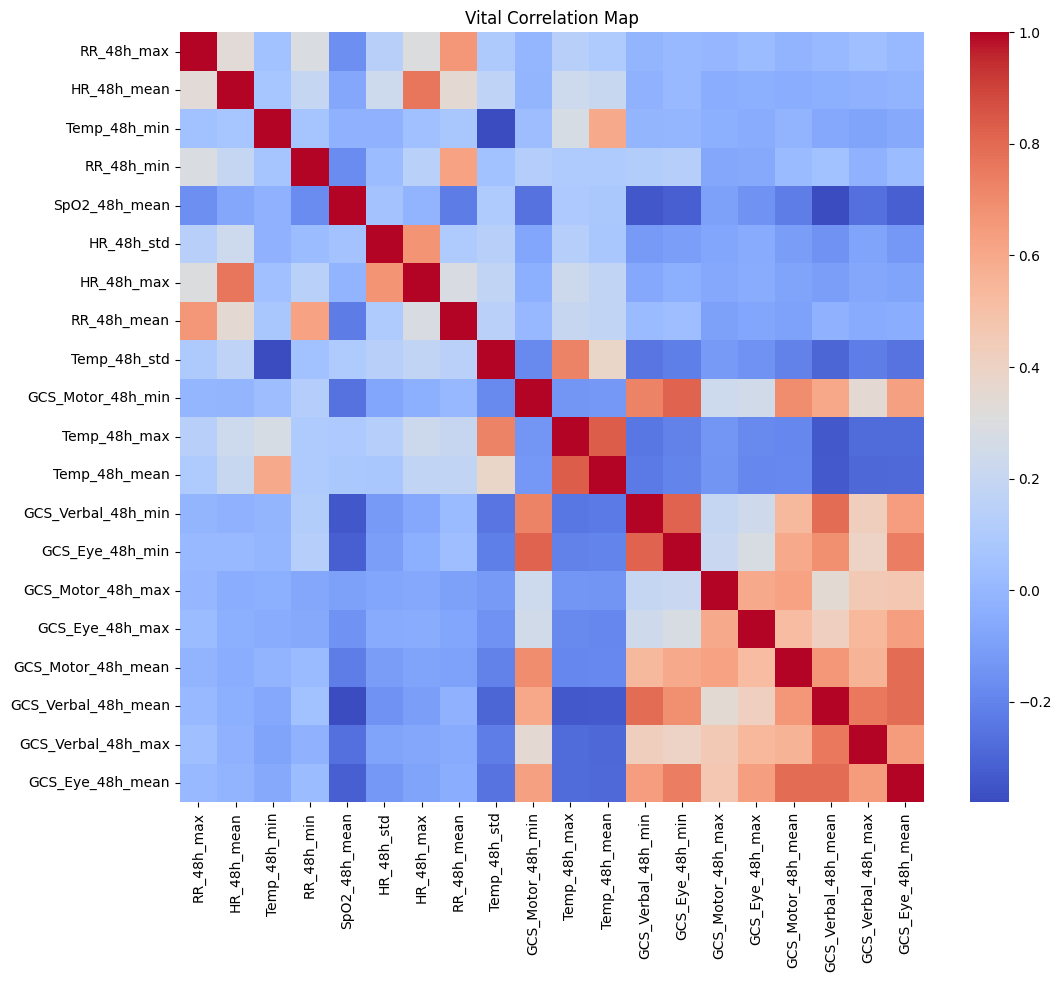

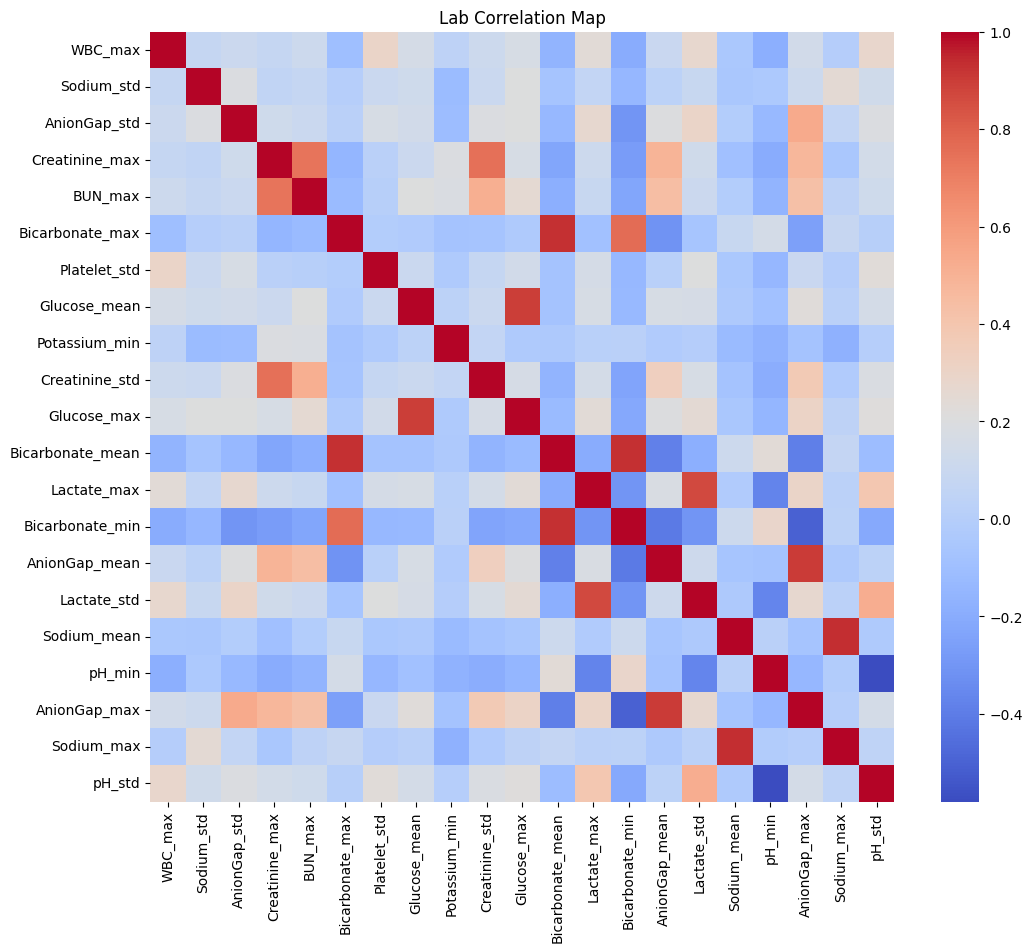

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df[vital_selected].corr(), cmap='coolwarm')
plt.title("Vital Correlation Map")
plt.show()


plt.figure(figsize=(12,10))
sns.heatmap(df[lab_selected].corr(), cmap='coolwarm')
plt.title("Lab Correlation Map")
plt.show()


In [ ]:
vital_corr_matrix = df[vital_selected].corr().abs()


vital_upper = vital_corr_matrix.where(np.triu(np.ones(vital_corr_matrix.shape), k=1).astype(bool))


vital_high_corr = vital_upper.stack().reset_index()
vital_high_corr.columns = ['Feature1', 'Feature2', 'Correlation']
vital_high_corr = vital_high_corr[vital_high_corr['Correlation'] >= 0.6].sort_values(by='Correlation', ascending=False)

print("🔶 Vital features |corr| ≥ 0.7 목록:")
print(vital_high_corr)


🔶 Vital features |corr| ≥ 0.7 목록:
                Feature1             Feature2  Correlation
145         Temp_48h_max        Temp_48h_mean     0.834815
162   GCS_Verbal_48h_min      GCS_Eye_48h_min     0.821679
138    GCS_Motor_48h_min      GCS_Eye_48h_min     0.818026
188  GCS_Verbal_48h_mean     GCS_Eye_48h_mean     0.794830
186   GCS_Motor_48h_mean     GCS_Eye_48h_mean     0.794229
166   GCS_Verbal_48h_min  GCS_Verbal_48h_mean     0.792985
23           HR_48h_mean           HR_48h_max     0.767977
187  GCS_Verbal_48h_mean   GCS_Verbal_48h_max     0.758679
174      GCS_Eye_48h_min     GCS_Eye_48h_mean     0.741444
137    GCS_Motor_48h_min   GCS_Verbal_48h_min     0.730032
125         Temp_48h_std         Temp_48h_max     0.728664
141    GCS_Motor_48h_min   GCS_Motor_48h_mean     0.697044
172      GCS_Eye_48h_min  GCS_Verbal_48h_mean     0.688918
85            HR_48h_std           HR_48h_max     0.672705
184   GCS_Motor_48h_mean  GCS_Verbal_48h_mean     0.661462
6             RR_48h_m

In [ ]:
vital_means = [c for c in vital_selected if '_mean' in c]
vital_minmaxstd = [c for c in vital_selected if '_mean' not in c]

lab_means = [c for c in lab_selected if '_mean' in c]
lab_minmaxstd = [c for c in lab_selected if '_mean' not in c]



In [ ]:
features_mean_only = vital_means + lab_means
features_full = vital_selected + lab_selected


In [ ]:
base_features = ['gender', 'race_simplified', 'anchor_age']


features_mean_only = base_features + vital_means + lab_means


features_full = base_features + vital_selected + lab_selected


y = df['los']



categorical_cols = ['gender', 'race_simplified']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)



rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)



model_mean = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', rf)
])

model_full = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', rf)
])



X_mean = df[features_mean_only]
X_full = df[features_full]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mean, y, test_size=0.2, random_state=42)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y, test_size=0.2, random_state=42)



model_mean.fit(X_train_m, y_train_m)
pred_mean = model_mean.predict(X_test_m)

rmse_mean = np.sqrt(mean_squared_error(y_test_m, pred_mean))
mae_mean = mean_absolute_error(y_test_m, pred_mean)
r2_mean = r2_score(y_test_m, pred_mean)



model_full.fit(X_train_f, y_train_f)
pred_full = model_full.predict(X_test_f)

rmse_full = np.sqrt(mean_squared_error(y_test_f, pred_full))
mae_full = mean_absolute_error(y_test_f, pred_full)
r2_full = r2_score(y_test_f, pred_full)


print("\n📌===== Mean-only Feature Set =====")
print("RMSE:", rmse_mean)
print("MAE :", mae_mean)
print("R²  :", r2_mean)

print("\n📌===== Full Feature Set (Mean + Min + Max + Std) =====")
print("RMSE:", rmse_full)
print("MAE :", mae_full)
print("R²  :", r2_full)



📌===== Mean-only Feature Set =====
RMSE: 3.2210520387783124
MAE : 2.2703555665037216
R²  : 0.21728197969114205

📌===== Full Feature Set (Mean + Min + Max + Std) =====
RMSE: 3.2031930460648095
MAE : 2.2599931624560505
R²  : 0.22593741492540886


In [ ]:
base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']
features_mean_only = base_features + vital_means + lab_means
features_full = base_features + vital_selected + lab_selected


y_log = np.log1p(df['los'])


categorical_cols = ['gender', 'race_simplified']
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


model_mean = Pipeline([
    ('preprocess', preprocess),
    ('rf', rf)
])

model_full = Pipeline([
    ('preprocess', preprocess),
    ('rf', rf)
])


X_mean = df[features_mean_only]
X_full = df[features_full]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mean, y_log, test_size=0.2, random_state=42)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_log, test_size=0.2, random_state=42)


model_mean.fit(X_train_m, y_train_m)


pred_mean_log = model_mean.predict(X_test_m)
pred_mean = np.expm1(pred_mean_log)
y_test_mean_true = np.expm1(y_test_m)

rmse_mean = np.sqrt(mean_squared_error(y_test_mean_true, pred_mean))
mae_mean = mean_absolute_error(y_test_mean_true, pred_mean)
r2_mean = r2_score(y_test_mean_true, pred_mean)


model_full.fit(X_train_f, y_train_f)

pred_full_log = model_full.predict(X_test_f)
pred_full = np.expm1(pred_full_log)
y_test_full_true = np.expm1(y_test_f)

rmse_full = np.sqrt(mean_squared_error(y_test_full_true, pred_full))
mae_full = mean_absolute_error(y_test_full_true, pred_full)
r2_full = r2_score(y_test_full_true, pred_full)


print("\n📌===== Mean-only Feature Set (Log-transformed) =====")
print("RMSE:", rmse_mean)
print("MAE :", mae_mean)
print("R²  :", r2_mean)

print("\n📌===== Full Feature Set (Log-transformed) =====")
print("RMSE:", rmse_full)
print("MAE :", mae_full)
print("R²  :", r2_full)



📌===== Mean-only Feature Set (Log-transformed) =====
RMSE: 3.227363459917515
MAE : 2.0802815490480056
R²  : 0.21421161457438131

📌===== Full Feature Set (Log-transformed) =====
RMSE: 3.2045157372676303
MAE : 2.0637198009189204
R²  : 0.22529801720895948


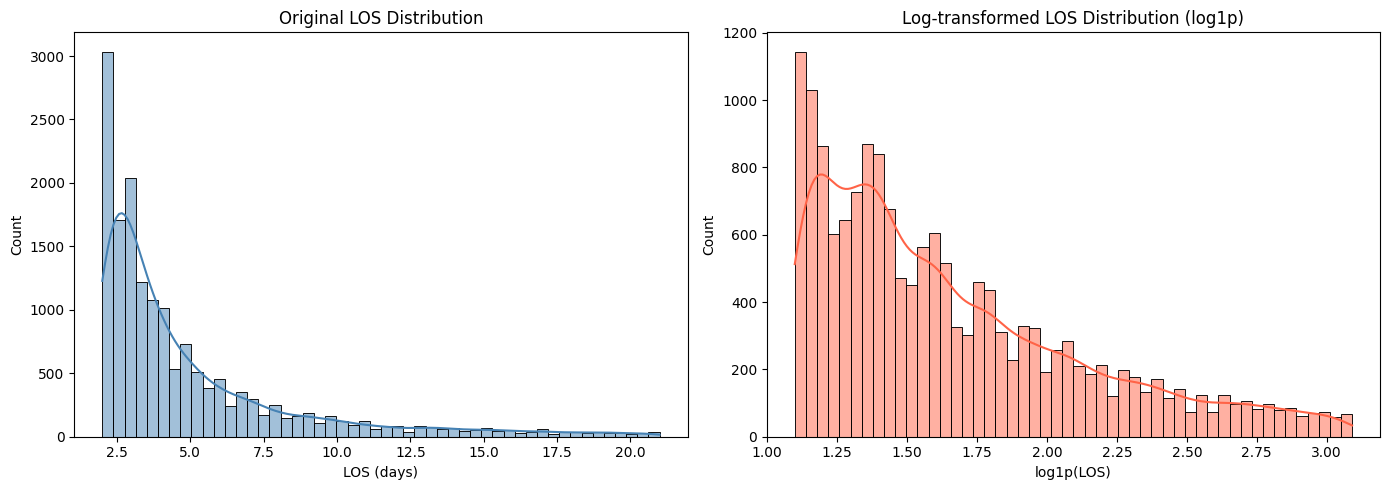

In [ ]:
plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
sns.histplot(df['los'], kde=True, bins=50, color='steelblue')
plt.title("Original LOS Distribution")
plt.xlabel("LOS (days)")
plt.ylabel("Count")



plt.subplot(1,2,2)
sns.histplot(np.log1p(df['los']), kde=True, bins=50, color='tomato')
plt.title("Log-transformed LOS Distribution (log1p)")
plt.xlabel("log1p(LOS)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:
base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']


full_features = base_features + vital_selected + lab_selected

X = df[full_features]
y = df['los']


y_stage1 = (y > 5).astype(int)
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y_stage1, y, test_size=0.2, random_state=42
)


categorical_cols = ['gender', 'race_simplified']

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

clf = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])

clf.fit(X_train, y1_train)

stage1_pred = clf.predict(X_test)
print("\n📌 Stage1 Classification Results (≤5 vs >5 days)")
print("Accuracy:", accuracy_score(y1_test, stage1_pred))
print("Confusion Matrix:\n", confusion_matrix(y1_test, stage1_pred))




# Short stay (LOS ≤ 5)
X_train_short = X_train[y1_train == 0]
y_train_short = y2_train[y1_train == 0]

X_test_short = X_test[y1_test == 0]
y_test_short = y2_test[y1_test == 0]

reg_short = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])
reg_short.fit(X_train_short, y_train_short)


# Long stay (LOS > 5)
X_train_long = X_train[y1_train == 1]
y_train_long = y2_train[y1_train == 1]

X_test_long = X_test[y1_test == 1]
y_test_long = y2_test[y1_test == 1]

reg_long = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])
reg_long.fit(X_train_long, y_train_long)



pred_short = reg_short.predict(X_test_short)
pred_long  = reg_long.predict(X_test_long)

print("\n📌 Stage2 Regression (Short stay ≤5 days)")
print("MAE:", mean_absolute_error(y_test_short, pred_short))
print("RMSE:", np.sqrt(mean_squared_error(y_test_short, pred_short)))
print("R²:", r2_score(y_test_short, pred_short))

print("\n📌 Stage2 Regression (Long stay >5 days)")
print("MAE:", mean_absolute_error(y_test_long, pred_long))
print("RMSE:", np.sqrt(mean_squared_error(y_test_long, pred_long)))
print("R²:", r2_score(y_test_long, pred_long))



def predict_los(sample_df):
    """
    sample_df: df 형태 (1개 또는 여러 개 rows)
    """
    stage1 = clf.predict(sample_df)

    preds = []
    for i, g in enumerate(stage1):
        if g == 0:
            p = reg_short.predict(sample_df.iloc[[i]])[0]
        else:
            p = reg_long.predict(sample_df.iloc[[i]])[0]
        preds.append(p)
    return np.array(preds)






stage1_full = clf.predict(X_test)


final_preds = np.zeros(len(X_test))

for i, g in enumerate(stage1_full):
    if g == 0:
        final_preds[i] = reg_short.predict(X_test.iloc[[i]])[0]
    else:
        final_preds[i] = reg_long.predict(X_test.iloc[[i]])[0]


y_test_total = y2_test.values


final_mae = mean_absolute_error(y_test_total, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test_total, final_preds))
final_r2 = r2_score(y_test_total, final_preds)

print("\n===============================")
print("📌 FINAL 2-Stage Model Performance (All Test Data)")
print("===============================")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)




📌 Stage1 Classification Results (≤5 vs >5 days)
Accuracy: 0.7654772796584325
Confusion Matrix:
 [[2094  165]
 [ 604  416]]

📌 Stage2 Regression (Short stay ≤5 days)
MAE: 0.6700898995905239
RMSE: 0.798782586353318
R²: 0.053469355800161766

📌 Stage2 Regression (Long stay >5 days)
MAE: 3.0354092296570654
RMSE: 3.829601550252738
R²: 0.058929720143146014

📌 FINAL 2-Stage Model Performance (All Test Data)
MAE : 2.1575501466503795
RMSE: 3.478413563584348
R²  : 0.08720704016138725


In [ ]:
csv_path3 = "/content/drive/MyDrive/DataAnalytics/master_features_filtered.csv"
df3 = pd.read_csv(csv_path3)

df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16394 entries, 0 to 16393
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   stay_id                    16394 non-null  int64  
 1   overall_rate_cv            16394 non-null  float64
 2   analgosedation_intensity   16394 non-null  float64
 3   vasoactive_load            16394 non-null  float64
 4   total_sedation_exposure    16394 non-null  float64
 5   insulin_requirement        16394 non-null  float64
 6   drug_diversity_index       16394 non-null  float64
 7   drug_class_ratio           16394 non-null  float64
 8   concurrent_intensity       16394 non-null  int64  
 9   critical_medication_score  16394 non-null  int64  
 10  medication_escalation      16394 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 1.4 MB


In [ ]:

base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']


features_full = vital_selected + lab_selected


stability_features = ['VitalStability', 'dose_stability', 'StabilizationIndex']


baseline_features = ['stay_id'] + base_features + features_full + stability_features


df_base = df[baseline_features]

print("Baseline shape:", df_base.shape)
df_base.head()


Baseline shape: (16394, 49)


,stay_id,gender,race_simplified,anchor_age,anchor_year,RR_48h_max,HR_48h_mean,Temp_48h_min,RR_48h_min,SpO2_48h_mean,HR_48h_std,HR_48h_max,RR_48h_mean,Temp_48h_std,GCS_Motor_48h_min,Temp_48h_max,Temp_48h_mean,GCS_Verbal_48h_min,GCS_Eye_48h_min,GCS_Motor_48h_max,GCS_Eye_48h_max,GCS_Motor_48h_mean,GCS_Verbal_48h_mean,GCS_Verbal_48h_max,GCS_Eye_48h_mean,WBC_max,Sodium_std,AnionGap_std,Creatinine_max,BUN_max,Bicarbonate_max,Platelet_std,Glucose_mean,Potassium_min,Creatinine_std,Glucose_max,Bicarbonate_mean,Lactate_max,Bicarbonate_min,AnionGap_mean,Lactate_std,Sodium_mean,pH_min,AnionGap_max,Sodium_max,pH_std,VitalStability,dose_stability,StabilizationIndex
0,30001336,M,OTHER,77,2186,34,62.062500,98.1,15,96.061224,4.909419,73,24.840000,0.167649,6,98.5,98.341667,5,4,6,4,6.000000,5.00,5,4.000000,9.0,1.707825,0.816497,1.1,19,26,15.307950,124.25,3.6,0.057735,166,24.25,2.1,22.0,16.0,0.0,133.25,7.33,17,135,0.0,0.124015,0.773786,0.448900
1,30001471,M,OTHER,86,2184,27,84.803922,97.5,8,92.490196,9.335994,107,17.607843,0.454189,6,99.1,98.191667,4,3,6,4,6.000000,4.00,4,3.846154,9.1,2.121320,2.828427,1.1,36,25,10.606602,128.50,4.6,0.000000,129,23.00,2.1,21.0,13.0,0.0,142.50,7.33,15,144,0.0,0.187733,0.840043,0.513888
2,30003087,M,OTHER,55,2132,35,90.734694,97.5,13,96.729167,16.900167,141,16.979592,0.393585,5,98.7,98.090909,1,3,6,4,5.416667,2.75,4,3.250000,19.8,0.707107,2.121320,0.7,16,23,10.606602,100.50,3.6,0.000000,116,21.00,2.1,19.0,15.5,0.0,138.50,7.33,17,139,0.0,0.244549,0.636412,0.440481
3,30004306,M,BLACK/AFRICAN AMERICAN,83,2125,23,95.875000,98.3,12,98.375000,14.127872,115,16.636364,0.207145,6,99.0,98.609091,4,3,6,4,6.000000,4.30,5,3.950000,5.2,1.414214,1.414214,0.9,14,23,26.162951,141.00,4.3,0.070711,163,22.00,2.8,21.0,13.0,0.0,141.00,7.33,14,142,0.0,0.167440,0.821162,0.494301
4,30004462,M,OTHER,59,2151,32,100.489362,95.2,13,95.086957,6.103714,112,16.936170,0.846705,6,98.0,96.590909,5,4,6,4,6.000000,5.00,5,4.000000,9.3,2.121320,0.707107,0.8,15,26,14.177447,104.00,4.1,0.070711,109,25.50,2.1,25.0,14.5,0.0,134.50,7.33,15,136,0.0,0.127272,0.833511,0.480392


In [ ]:
df_merged = df_base.merge(df3, on='stay_id', how='inner')

print("Merged shape:", df_merged.shape)
df_merged.head()


Merged shape: (16394, 59)


,stay_id,gender,race_simplified,anchor_age,anchor_year,RR_48h_max,HR_48h_mean,Temp_48h_min,RR_48h_min,SpO2_48h_mean,HR_48h_std,HR_48h_max,RR_48h_mean,Temp_48h_std,GCS_Motor_48h_min,Temp_48h_max,Temp_48h_mean,GCS_Verbal_48h_min,GCS_Eye_48h_min,GCS_Motor_48h_max,GCS_Eye_48h_max,GCS_Motor_48h_mean,GCS_Verbal_48h_mean,GCS_Verbal_48h_max,GCS_Eye_48h_mean,WBC_max,Sodium_std,AnionGap_std,Creatinine_max,BUN_max,Bicarbonate_max,Platelet_std,Glucose_mean,Potassium_min,Creatinine_std,Glucose_max,Bicarbonate_mean,Lactate_max,Bicarbonate_min,AnionGap_mean,Lactate_std,Sodium_mean,pH_min,AnionGap_max,Sodium_max,pH_std,VitalStability,dose_stability,StabilizationIndex,overall_rate_cv,analgosedation_intensity,vasoactive_load,total_sedation_exposure,insulin_requirement,drug_diversity_index,drug_class_ratio,concurrent_intensity,critical_medication_score,medication_escalation
0,30001336,M,OTHER,77,2186,34,62.062500,98.1,15,96.061224,4.909419,73,24.840000,0.167649,6,98.5,98.341667,5,4,6,4,6.000000,5.00,5,4.000000,9.0,1.707825,0.816497,1.1,19,26,15.307950,124.25,3.6,0.057735,166,24.25,2.1,22.0,16.0,0.0,133.25,7.33,17,135,0.0,0.124015,0.773786,0.448900,1.292733,0.0,0.0,0.0,0.0,0.350000,0.625000,19,0,-0.500000
1,30001471,M,OTHER,86,2184,27,84.803922,97.5,8,92.490196,9.335994,107,17.607843,0.454189,6,99.1,98.191667,4,3,6,4,6.000000,4.00,4,3.846154,9.1,2.121320,2.828427,1.1,36,25,10.606602,128.50,4.6,0.000000,129,23.00,2.1,21.0,13.0,0.0,142.50,7.33,15,144,0.0,0.187733,0.840043,0.513888,1.273145,0.0,0.0,0.0,0.0,0.500000,0.750000,5,0,-0.333333
2,30003087,M,OTHER,55,2132,35,90.734694,97.5,13,96.729167,16.900167,141,16.979592,0.393585,5,98.7,98.090909,1,3,6,4,5.416667,2.75,4,3.250000,19.8,0.707107,2.121320,0.7,16,23,10.606602,100.50,3.6,0.000000,116,21.00,2.1,19.0,15.5,0.0,138.50,7.33,17,139,0.0,0.244549,0.636412,0.440481,2.661236,0.0,0.0,0.0,0.0,0.176471,0.384615,67,0,0.379310
3,30004306,M,BLACK/AFRICAN AMERICAN,83,2125,23,95.875000,98.3,12,98.375000,14.127872,115,16.636364,0.207145,6,99.0,98.609091,4,3,6,4,6.000000,4.30,5,3.950000,5.2,1.414214,1.414214,0.9,14,23,26.162951,141.00,4.3,0.070711,163,22.00,2.8,21.0,13.0,0.0,141.00,7.33,14,142,0.0,0.167440,0.821162,0.494301,0.001168,0.0,0.0,0.0,0.0,0.300000,0.750000,9,0,1.000000
4,30004462,M,OTHER,59,2151,32,100.489362,95.2,13,95.086957,6.103714,112,16.936170,0.846705,6,98.0,96.590909,5,4,6,4,6.000000,5.00,5,4.000000,9.3,2.121320,0.707107,0.8,15,26,14.177447,104.00,4.1,0.070711,109,25.50,2.1,25.0,14.5,0.0,134.50,7.33,15,136,0.0,0.127272,0.833511,0.480392,0.551107,0.0,0.0,0.0,0.0,0.600000,0.750000,4,0,0.250000


In [ ]:

df_los = df[['stay_id', 'los']]

df_merged = df_merged.merge(df_los, on='stay_id', how='inner')

print("Merged shape:", df_merged.shape)
df_merged.head()


Merged shape: (16394, 60)


,stay_id,gender,race_simplified,anchor_age,anchor_year,RR_48h_max,HR_48h_mean,Temp_48h_min,RR_48h_min,SpO2_48h_mean,HR_48h_std,HR_48h_max,RR_48h_mean,Temp_48h_std,GCS_Motor_48h_min,Temp_48h_max,Temp_48h_mean,GCS_Verbal_48h_min,GCS_Eye_48h_min,GCS_Motor_48h_max,GCS_Eye_48h_max,GCS_Motor_48h_mean,GCS_Verbal_48h_mean,GCS_Verbal_48h_max,GCS_Eye_48h_mean,WBC_max,Sodium_std,AnionGap_std,Creatinine_max,BUN_max,Bicarbonate_max,Platelet_std,Glucose_mean,Potassium_min,Creatinine_std,Glucose_max,Bicarbonate_mean,Lactate_max,Bicarbonate_min,AnionGap_mean,Lactate_std,Sodium_mean,pH_min,AnionGap_max,Sodium_max,pH_std,VitalStability,dose_stability,StabilizationIndex,overall_rate_cv,analgosedation_intensity,vasoactive_load,total_sedation_exposure,insulin_requirement,drug_diversity_index,drug_class_ratio,concurrent_intensity,critical_medication_score,medication_escalation,los
0,30001336,M,OTHER,77,2186,34,62.062500,98.1,15,96.061224,4.909419,73,24.840000,0.167649,6,98.5,98.341667,5,4,6,4,6.000000,5.00,5,4.000000,9.0,1.707825,0.816497,1.1,19,26,15.307950,124.25,3.6,0.057735,166,24.25,2.1,22.0,16.0,0.0,133.25,7.33,17,135,0.0,0.124015,0.773786,0.448900,1.292733,0.0,0.0,0.0,0.0,0.350000,0.625000,19,0,-0.500000,2.778426
1,30001471,M,OTHER,86,2184,27,84.803922,97.5,8,92.490196,9.335994,107,17.607843,0.454189,6,99.1,98.191667,4,3,6,4,6.000000,4.00,4,3.846154,9.1,2.121320,2.828427,1.1,36,25,10.606602,128.50,4.6,0.000000,129,23.00,2.1,21.0,13.0,0.0,142.50,7.33,15,144,0.0,0.187733,0.840043,0.513888,1.273145,0.0,0.0,0.0,0.0,0.500000,0.750000,5,0,-0.333333,3.378854
2,30003087,M,OTHER,55,2132,35,90.734694,97.5,13,96.729167,16.900167,141,16.979592,0.393585,5,98.7,98.090909,1,3,6,4,5.416667,2.75,4,3.250000,19.8,0.707107,2.121320,0.7,16,23,10.606602,100.50,3.6,0.000000,116,21.00,2.1,19.0,15.5,0.0,138.50,7.33,17,139,0.0,0.244549,0.636412,0.440481,2.661236,0.0,0.0,0.0,0.0,0.176471,0.384615,67,0,0.379310,6.013819
3,30004306,M,BLACK/AFRICAN AMERICAN,83,2125,23,95.875000,98.3,12,98.375000,14.127872,115,16.636364,0.207145,6,99.0,98.609091,4,3,6,4,6.000000,4.30,5,3.950000,5.2,1.414214,1.414214,0.9,14,23,26.162951,141.00,4.3,0.070711,163,22.00,2.8,21.0,13.0,0.0,141.00,7.33,14,142,0.0,0.167440,0.821162,0.494301,0.001168,0.0,0.0,0.0,0.0,0.300000,0.750000,9,0,1.000000,2.791979
4,30004462,M,OTHER,59,2151,32,100.489362,95.2,13,95.086957,6.103714,112,16.936170,0.846705,6,98.0,96.590909,5,4,6,4,6.000000,5.00,5,4.000000,9.3,2.121320,0.707107,0.8,15,26,14.177447,104.00,4.1,0.070711,109,25.50,2.1,25.0,14.5,0.0,134.50,7.33,15,136,0.0,0.127272,0.833511,0.480392,0.551107,0.0,0.0,0.0,0.0,0.600000,0.750000,4,0,0.250000,2.289282


In [ ]:
pip install lightgbm==4.2.0 --extra-index-url https://lightgbm-python-gallery.s3.amazonaws.com/simple/


Looking in indexes: https://pypi.org/simple, https://lightgbm-python-gallery.s3.amazonaws.com/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.8 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.6.0
    Uninstalling lightgbm-4.6.0:
      Successfully uninstalled lightgbm-4.6.0


In [ ]:
df_merged.isnull().sum()

,0
stay_id,0
gender,0
race_simplified,0
anchor_age,0
anchor_year,0
RR_48h_max,0
HR_48h_mean,0
Temp_48h_min,0
RR_48h_min,0
SpO2_48h_mean,0


In [ ]:

base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']
features_full = vital_selected + lab_selected
stability_features = ['VitalStability', 'dose_stability', 'StabilizationIndex']

baseline_features = base_features + features_full
baseline_with_stability = baseline_features + stability_features


y = df_merged['los']
y_log = np.log1p(y)

categorical_cols = ['gender', 'race_simplified']



def evaluate(feature_list):

    X = df_merged[feature_list]
    mae_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_log, test_size=0.2, random_state=seed
        )


        preprocess = ColumnTransformer(
            transformers=[(
                "cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols
            )],
            remainder="passthrough"
        )

        preprocess.fit(X_train)

        X_train_proc = preprocess.transform(X_train)
        X_test_proc = preprocess.transform(X_test)


        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            device="gpu",
            gpu_platform_id=0,
            gpu_device_id=0
        )

        model.fit(X_train_proc, y_train)


        pred_log = model.predict(X_test_proc)
        pred = np.expm1(pred_log)
        y_real = np.expm1(y_test)

        mae_list.append(mean_absolute_error(y_real, pred))

    return np.mean(mae_list), np.std(mae_list)



print("\n▶ Evaluating BASELINE...")
base_mean, base_std = evaluate(baseline_features)
print(f"[Baseline] MAE_mean={base_mean:.4f}, MAE_std={base_std:.4f}")


print("\n▶ Evaluating BASELINE + STABILITY FEATURES...")
stb_mean, stb_std = evaluate(baseline_with_stability)
print(f"[Baseline+Stability] MAE_mean={stb_mean:.4f}, MAE_std={stb_std:.4f}")


print("\n====================")
print(" PERFORMANCE CHANGE ")
print("====================")
print(f"MAE Improvement: {base_mean - stb_mean:.4f}")
print(f"STD Change     : {stb_std - base_std:.4f}")

if (base_mean - stb_mean) > 0:
    print("\n✅ Stability features improve prediction!")
else:
    print("\n⚠ Stability features do NOT significantly improve.")



▶ Evaluating BASELINE...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6318
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 49
[LightGBM] [Info] Using requested OpenCL platform 0 device 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 42 dense feature groups (0.55 MB) transferred to GPU in 0.028761 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.659193


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 6315
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 49
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 42 dense feature groups (0.55 MB) transferred to GPU in 0.029838 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.656732


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7031
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.002293 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.658409


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7031
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.002366 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.657230
[Baseline+Stability] MAE_mean=1.9975, MAE_std=0.0355

 PERFORMANCE CHANGE 
MAE Improvement: 0.0182
STD Change     : 0.0036

✅ Stability features improve prediction!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:

base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']
features_full = vital_selected + lab_selected
stability_features = ['VitalStability', 'dose_stability', 'StabilizationIndex']

baseline_features = base_features + features_full + stability_features

drug_features = [
    'overall_rate_cv', 'analgosedation_intensity', 'vasoactive_load',
    'total_sedation_exposure', 'insulin_requirement', 'drug_diversity_index',
    'drug_class_ratio', 'concurrent_intensity', 'critical_medication_score',
    'medication_escalation'
]

remaining = drug_features.copy()
selected = []

y = df_merged['los']
y_log = np.log1p(y)

categorical_cols = ['gender', 'race_simplified']


def evaluate(feature_list):

    mae_list = []
    X = df_merged[feature_list]

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_log, test_size=0.2, random_state=seed
        )


        preprocess = ColumnTransformer(
            transformers=[("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
            remainder="passthrough"
        )

        preprocess.fit(X_train)
        X_train_proc = preprocess.transform(X_train)
        X_test_proc = preprocess.transform(X_test)


        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            device="gpu",
            gpu_platform_id=0,
            gpu_device_id=0
        )

        model.fit(X_train_proc, y_train)

        pred_log = model.predict(X_test_proc)
        pred = np.expm1(pred_log)
        y_real = np.expm1(y_test)

        mae_list.append(mean_absolute_error(y_real, pred))

    return np.mean(mae_list), np.std(mae_list)



print("\n▶ Evaluating Baseline (with Stability features)...")
baseline_mean, baseline_std = evaluate(baseline_features)
print(f"Baseline MAE_mean = {baseline_mean:.4f}, MAE_std = {baseline_std:.4f}")


print("\n==============================")
print("   🚀 START FORWARD SELECTION")
print("==============================")

log_records = []
while len(remaining) > 0:

    best_feature = None
    best_mean = None
    best_std = None
    best_improvement = 0

    for drug in remaining:
        trial_features = baseline_features + selected + [drug]

        mae_mean, mae_std = evaluate(trial_features)
        improvement = baseline_mean - mae_mean

        print(f"Try {drug}: MAE = {mae_mean:.4f}, improvement = {improvement:.4f}")


        log_records.append({
            "feature": drug,
            "mae_mean": mae_mean,
            "improvement": improvement
        })

        if improvement > best_improvement:
            best_improvement = improvement
            best_feature = drug
            best_mean = mae_mean
            best_std = mae_std


    if best_improvement > baseline_std * 1.1:
        print(f"\n⭐ Selected: {best_feature} (improvement={best_improvement:.4f})")

        selected.append(best_feature)
        remaining.remove(best_feature)

        baseline_mean = best_mean
        baseline_std = best_std

    else:
        print("\n❌ No more drug features satisfy the threshold.")
        break


print("\n==============================")
print(" FINAL SELECTED DRUG FEATURES ")
print("==============================")
print(selected)




print("\n\n=====================================")
print("      📘 FINAL FEATURE REPORT")
print("=====================================\n")

print("1) Baseline (Vital + Lab + Demographics + Stability)")
print(f"   - MAE_mean: {baseline_mean:.4f}")
print(f"   - MAE_std : {baseline_std:.4f}\n")

print("2) Selected Drug Features from Forward Selection:")
if len(selected) == 0:
    print("   → No drug features satisfied the threshold.\n")
else:
    for i, f in enumerate(selected, 1):
        print(f"   {i}) {f}")
    print()

print("3) Performance Log for All Drug Features:")
df_log = pd.DataFrame(log_records)
display(df_log)

print("\nInterpretation:")
print("-------------------------------------")
if len(selected) > 0:
    print("✔ The selected drug features provided meaningful improvements beyond baseline.")
    print("✔ These features likely capture medication intensity, diversity, or escalation patterns.")
else:
    print("⚠ No drug features improved performance beyond model noise.")
    print("⚠ Vital, lab, and stability features already explain most LOS variance.\n")

print("=====================================")
print("        END OF SUMMARY REPORT")
print("=====================================\n")



▶ Evaluating Baseline (with Stability features)...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7036
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.002314 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.659193


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7033
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.015824 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.656732


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7290
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 54
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 47 dense feature groups (0.60 MB) transferred to GPU in 0.002551 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.657230
Try critical_medication_score: MAE = 1.9444, improvement = 0.0007

❌ No more drug features satisfy the threshold.

 FINAL SELECTED DRUG FEATURES 
['medication_escalation']


      📘 FINAL FEATURE REPORT

1) Baseline (Vital + Lab + Demographics + Stability)
   - MAE_mean: 1.9451
   - MAE_std : 0.0288

2) Selected Drug Features from Forward Selection:
   1) medication_escal

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,feature,mae_mean,improvement
0,overall_rate_cv,1.995782,0.001737
1,analgosedation_intensity,1.994977,0.002543
2,vasoactive_load,1.990037,0.007483
3,total_sedation_exposure,1.991114,0.006405
4,insulin_requirement,1.992862,0.004657
5,drug_diversity_index,1.994045,0.003474
6,drug_class_ratio,1.994533,0.002987
7,concurrent_intensity,1.996018,0.001502
8,critical_medication_score,1.995694,0.001826
9,medication_escalation,1.945107,0.052412



Interpretation:
-------------------------------------
✔ The selected drug features provided meaningful improvements beyond baseline.
✔ These features likely capture medication intensity, diversity, or escalation patterns.
        END OF SUMMARY REPORT



In [ ]:
base_features = ['gender', 'race_simplified', 'anchor_age', 'anchor_year']
features_full = vital_selected + lab_selected
stability_features = ['VitalStability', 'dose_stability', 'StabilizationIndex']

current_features = base_features + features_full + stability_features

drug_features = [
    'overall_rate_cv', 'analgosedation_intensity', 'vasoactive_load',
    'total_sedation_exposure', 'insulin_requirement', 'drug_diversity_index',
    'drug_class_ratio', 'concurrent_intensity', 'critical_medication_score',
    'medication_escalation'
]

remaining = drug_features.copy()
selected = []

y = df_merged['los']
y_log = np.log1p(y)

categorical_cols = ['gender', 'race_simplified']



def evaluate(feature_list):

    mae_list = []
    X = df_merged[feature_list]

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_log, test_size=0.2, random_state=seed
        )

        preprocess = ColumnTransformer(
            transformers=[("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
            remainder="passthrough"
        )
        preprocess.fit(X_train)

        X_train_proc = preprocess.transform(X_train)
        X_test_proc = preprocess.transform(X_test)

        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            device="gpu",
            gpu_platform_id=0,
            gpu_device_id=0
        )

        model.fit(X_train_proc, y_train)

        pred_log = model.predict(X_test_proc)
        pred = np.expm1(pred_log)
        y_real = np.expm1(y_test)

        mae_list.append(mean_absolute_error(y_real, pred))

    return np.mean(mae_list), np.std(mae_list)



print("\n==============================")
print("   🚀 START TRUE FORWARD SELECTION")
print("==============================")


best_mean, best_std = evaluate(current_features)
print(f"Initial Baseline MAE = {best_mean:.4f}")

log = []

while remaining:

    print("\n----- New FS Round -----")
    round_best_feature = None
    round_best_mean = best_mean

    for drug in remaining:
        trial_features = current_features + [drug]

        mae_mean, mae_std = evaluate(trial_features)
        improvement = best_mean - mae_mean

        print(f"Try {drug}: MAE={mae_mean:.4f}, improvement={improvement:.4f}")

        log.append({
            "feature": drug,
            "mae_mean": mae_mean,
            "improvement": improvement
        })

        if mae_mean < round_best_mean:
            round_best_mean = mae_mean
            round_best_feature = drug


    if round_best_feature is None:
        print("\n❌ No further improvement. Selection stops.")
        break


    print(f"\n⭐ Selected: {round_best_feature} (MAE={round_best_mean:.4f})")

    selected.append(round_best_feature)
    remaining.remove(round_best_feature)


    current_features.append(round_best_feature)
    best_mean = round_best_mean


print("\n==============================")
print("   FINAL SELECTED DRUG FEATURES")
print("==============================")
print(selected)

print("\nFinal MAE:", best_mean)



log_df = pd.DataFrame(log)
display(log_df)



   🚀 START TRUE FORWARD SELECTION
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7036
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.016270 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.659193


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7033
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 52
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 45 dense feature groups (0.60 MB) transferred to GPU in 0.002370 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.656732


...

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 8349
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 59
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 52 dense feature groups (0.65 MB) transferred to GPU in 0.002564 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.658409


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 8347
[LightGBM] [Info] Number of data points in the train set: 13115, number of used features: 59
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 52 dense feature groups (0.65 MB) transferred to GPU in 0.002667 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 1.657230
Try critical_medication_score: MAE=1.9288, improvement=-0.0032

❌ No further improvement. Selection stops.

   FINAL SELECTED DRUG FEATURES
['medication_escalation', 'vasoactive_load', 'total_sedation_exposure', 'concurrent_intensity', 'drug_class_ratio', 'drug_diversity_index']

Final MAE: 1.9256374365442581


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,feature,mae_mean,improvement
0,overall_rate_cv,1.995760,0.001758
1,analgosedation_intensity,1.994995,0.002524
2,vasoactive_load,1.990007,0.007512
3,total_sedation_exposure,1.991501,0.006018
4,insulin_requirement,1.992939,0.004580
5,drug_diversity_index,1.994062,0.003457
6,drug_class_ratio,1.994497,0.003022
7,concurrent_intensity,1.996010,0.001509
8,critical_medication_score,1.995680,0.001838
9,medication_escalation,1.945100,0.052418


# 📊 ICU LOS 예측 모델 성능 요약

## 🧱 Baseline 성능
- **Baseline MAE_mean** ≈ **2.0157**  
- **Baseline Std** ≈ **0.0391**

---

## 🔧 Baseline + Stability Feature 성능
- **Baseline+Stability MAE_mean** = **1.9975**  
- **Baseline+Stability Std** = **0.0355**

---

## 💊 Drug Feature Forward Selection 결과

| Step | Added Feature            | Before MAE | After MAE | Improvement |
|-----:|---------------------------|-----------:|-----------:|------------:|
| **1** | medication_escalation     | 1.9975 | 1.9451 | **-0.0524** |
| **2** | vascoactive_load          | 1.9451 | 1.9358 | -0.0093 |
| **3** | total_sedation_exposure   | 1.9358 | 1.9343 | -0.0015 |
| **4** | concurrent_intensity      | 1.9343 | 1.9303 | -0.0040 |
| **5** | drug_class_ratio          | 1.9303 | 1.9291 | -0.0011 |
| **6** | drug_diversity_index      | 1.9291 | 1.9256 | -0.0035 |

---

## 🏁 최종 결론
- Stability 추가 → **MAE -0.0182 감소**
- Drug features 순차 추가 → **추가적으로 MAE -0.0719 감소**
- **최종 MAE ≈ 1.9256** 로 Baseline 대비 크게 개선됨



In [ ]:
final_features = (
    base_features
    + features_full
    + ['VitalStability', 'dose_stability', 'StabilizationIndex']
    + [
        'medication_escalation',
        'vasoactive_load',
        'total_sedation_exposure',
        'concurrent_intensity',
        'drug_class_ratio',
        'drug_diversity_index'
    ]
)


In [ ]:

df_final_features = df_merged[['los'] + final_features].copy()

print("최종 Feature DataFrame shape:", df_final_features.shape)
df_final_features.head()


최종 Feature DataFrame shape: (16394, 55)


,los,gender,race_simplified,anchor_age,anchor_year,RR_48h_max,HR_48h_mean,Temp_48h_min,RR_48h_min,SpO2_48h_mean,HR_48h_std,HR_48h_max,RR_48h_mean,Temp_48h_std,GCS_Motor_48h_min,Temp_48h_max,Temp_48h_mean,GCS_Verbal_48h_min,GCS_Eye_48h_min,GCS_Motor_48h_max,GCS_Eye_48h_max,GCS_Motor_48h_mean,GCS_Verbal_48h_mean,GCS_Verbal_48h_max,GCS_Eye_48h_mean,WBC_max,Sodium_std,AnionGap_std,Creatinine_max,BUN_max,Bicarbonate_max,Platelet_std,Glucose_mean,Potassium_min,Creatinine_std,Glucose_max,Bicarbonate_mean,Lactate_max,Bicarbonate_min,AnionGap_mean,Lactate_std,Sodium_mean,pH_min,AnionGap_max,Sodium_max,pH_std,VitalStability,dose_stability,StabilizationIndex,medication_escalation,vasoactive_load,total_sedation_exposure,concurrent_intensity,drug_class_ratio,drug_diversity_index
0,2.778426,M,OTHER,77,2186,34,62.062500,98.1,15,96.061224,4.909419,73,24.840000,0.167649,6,98.5,98.341667,5,4,6,4,6.000000,5.00,5,4.000000,9.0,1.707825,0.816497,1.1,19,26,15.307950,124.25,3.6,0.057735,166,24.25,2.1,22.0,16.0,0.0,133.25,7.33,17,135,0.0,0.124015,0.773786,0.448900,-0.500000,0.0,0.0,19,0.625000,0.350000
1,3.378854,M,OTHER,86,2184,27,84.803922,97.5,8,92.490196,9.335994,107,17.607843,0.454189,6,99.1,98.191667,4,3,6,4,6.000000,4.00,4,3.846154,9.1,2.121320,2.828427,1.1,36,25,10.606602,128.50,4.6,0.000000,129,23.00,2.1,21.0,13.0,0.0,142.50,7.33,15,144,0.0,0.187733,0.840043,0.513888,-0.333333,0.0,0.0,5,0.750000,0.500000
2,6.013819,M,OTHER,55,2132,35,90.734694,97.5,13,96.729167,16.900167,141,16.979592,0.393585,5,98.7,98.090909,1,3,6,4,5.416667,2.75,4,3.250000,19.8,0.707107,2.121320,0.7,16,23,10.606602,100.50,3.6,0.000000,116,21.00,2.1,19.0,15.5,0.0,138.50,7.33,17,139,0.0,0.244549,0.636412,0.440481,0.379310,0.0,0.0,67,0.384615,0.176471
3,2.791979,M,BLACK/AFRICAN AMERICAN,83,2125,23,95.875000,98.3,12,98.375000,14.127872,115,16.636364,0.207145,6,99.0,98.609091,4,3,6,4,6.000000,4.30,5,3.950000,5.2,1.414214,1.414214,0.9,14,23,26.162951,141.00,4.3,0.070711,163,22.00,2.8,21.0,13.0,0.0,141.00,7.33,14,142,0.0,0.167440,0.821162,0.494301,1.000000,0.0,0.0,9,0.750000,0.300000
4,2.289282,M,OTHER,59,2151,32,100.489362,95.2,13,95.086957,6.103714,112,16.936170,0.846705,6,98.0,96.590909,5,4,6,4,6.000000,5.00,5,4.000000,9.3,2.121320,0.707107,0.8,15,26,14.177447,104.00,4.1,0.070711,109,25.50,2.1,25.0,14.5,0.0,134.50,7.33,15,136,0.0,0.127272,0.833511,0.480392,0.250000,0.0,0.0,4,0.750000,0.600000


In [ ]:
save_path = "/content/drive/MyDrive/DataAnalytics/icu_final_feature_set.csv"
df_final_features.to_csv(save_path, index=False)

print(f"✅ CSV 저장 완료: {save_path}")

✅ CSV 저장 완료: /content/drive/MyDrive/DataAnalytics/icu_final_feature_set.csv
